In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [3]:
type1 = pd.read_csv('type1_diabetes.csv')
type1

,DIBAGE1,DIFAGE2,HYPEV,CHLEV,CHDEV,ANGEV,MIEV,HRTEV,STREV,EPHEV,...,ULCEV,ULCCOLEV,CANEV,SINYR,CBRCHYR,KIDWKYR,LIVYR,ARTH1,VIM_GLEV,FLA1AR
0,9.0,9.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8.0,35.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,15.0,36.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,38.0,14.0,1,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,1
4,85.0,0.0,1,1,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,80.0,5.0,1,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
370,18.0,4.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
371,6.0,34.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
372,82.0,3.0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1


In [4]:
def age_by_group(df):
    # Adjusted bins and labels to match appropriately
    bins = [0, 18, 30, 50, 70, 100]  # Bins should match the age ranges you want
    labels = ['<18', '18-30', '30-50', '50-70', '70+']  # Labels match the number of bins
    df['Age_Group'] = pd.cut(df['DIBAGE1'], bins=bins, labels=labels, right=False)  # Use right=False to include 18 in '18-30'
    df = df.drop(columns=['DIBAGE1', 'DIFAGE2'])
    return df

# Apply the function to type1_df2
type1_df2 = age_by_group(type1)

# Display the updated DataFrame
type1_df2

,HYPEV,CHLEV,CHDEV,ANGEV,MIEV,HRTEV,STREV,EPHEV,COPDEV,AASMEV,...,ULCCOLEV,CANEV,SINYR,CBRCHYR,KIDWKYR,LIVYR,ARTH1,VIM_GLEV,FLA1AR,Age_Group
0,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,<18
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,<18
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,<18
3,1,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,1,30-50
4,1,1,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,1,70+
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,1,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,70+
370,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,18-30
371,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,<18
372,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,70+


In [5]:
import pandas as pd

# Assuming you have the type1_df2 dataframe
columns = type1_df2.columns

# Split the columns into multiple rows for better presentation (adjust n_columns as necessary)
n_columns = 3  # You can change this based on how many columns per row you want
column_table = [columns[i:i + n_columns] for i in range(0, len(columns), n_columns)]

# Convert it into a DataFrame to visualize as a table
column_df = pd.DataFrame(column_table)
print(column_df.to_string(index=False))


       0      1         2
   HYPEV  CHLEV     CHDEV
   ANGEV   MIEV     HRTEV
   STREV  EPHEV    COPDEV
  AASMEV  ULCEV  ULCCOLEV
   CANEV  SINYR   CBRCHYR
 KIDWKYR  LIVYR     ARTH1
VIM_GLEV FLA1AR Age_Group


Text(0, 0.5, 'Count')

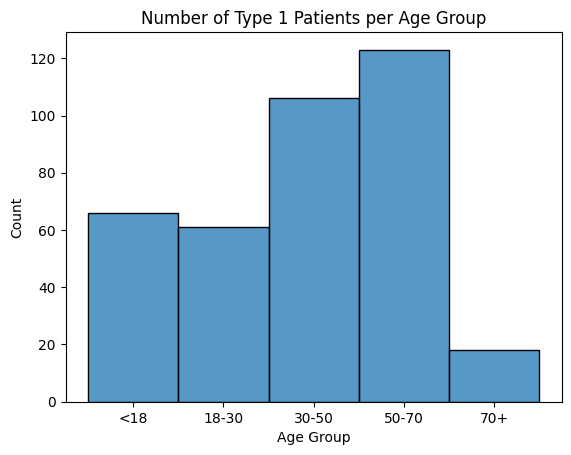

In [6]:
# Check the distribution of patients in each age group
#age_group_counts = type1['Age_Group'].value_counts().sort_index()

# Display the result
sns.histplot(type1_df2['Age_Group'])
plt.title("Number of Type 1 Patients per Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")

In [7]:
complications = ['HYPEV', 'CHLEV', 'CHDEV', 'ANGEV', 'MIEV', 'HRTEV', 'STREV', 'EPHEV',
                  'COPDEV', 'AASMEV', 'ULCEV', 'ULCCOLEV', 'CANEV', 'SINYR', 'CBRCHYR', 
                  'KIDWKYR', 'LIVYR', 'ARTH1', 'VIM_GLEV', 'FLA1AR']

In [8]:
# Set custom order for Age_Group to ensure <18 is on top
age_order = ['<18', '18-30', '30-50', '50-70', '70+']  # Using the specified age groups
type1_df2['Age_Group'] = pd.Categorical(type1_df2['Age_Group'], categories=age_order, ordered=True)

# Calculate the proportion of patients with complications for each age group
complication_proportion = type1_df2.groupby('Age_Group')[complications].apply(lambda x: (x > 0).mean())

# Display the result
complication_proportion

,HYPEV,CHLEV,CHDEV,ANGEV,MIEV,HRTEV,STREV,EPHEV,COPDEV,AASMEV,ULCEV,ULCCOLEV,CANEV,SINYR,CBRCHYR,KIDWKYR,LIVYR,ARTH1,VIM_GLEV,FLA1AR
Age_Group,,,,,,,,,,,,,,,,,,,,
<18,0.348485,0.378788,0.121212,0.106061,0.106061,0.151515,0.075758,0.030303,0.030303,0.242424,0.106061,0.000000,0.075758,0.257576,0.075758,0.121212,0.015152,0.242424,0.015152,0.424242
18-30,0.442623,0.491803,0.114754,0.081967,0.081967,0.098361,0.098361,0.032787,0.032787,0.278689,0.032787,0.016393,0.081967,0.180328,0.016393,0.065574,0.000000,0.262295,0.065574,0.573770
30-50,0.707547,0.566038,0.103774,0.037736,0.047170,0.160377,0.066038,0.047170,0.084906,0.198113,0.094340,0.000000,0.075472,0.094340,0.084906,0.056604,0.047170,0.462264,0.047170,0.603774
50-70,0.804878,0.617886,0.162602,0.032520,0.121951,0.178862,0.130081,0.065041,0.154472,0.130081,0.121951,0.008130,0.154472,0.186992,0.081301,0.089431,0.016260,0.487805,0.105691,0.747967
70+,0.833333,0.666667,0.444444,0.166667,0.333333,0.388889,0.222222,0.000000,0.111111,0.000000,0.277778,0.000000,0.277778,0.166667,0.055556,0.055556,0.000000,0.444444,0.055556,0.833333


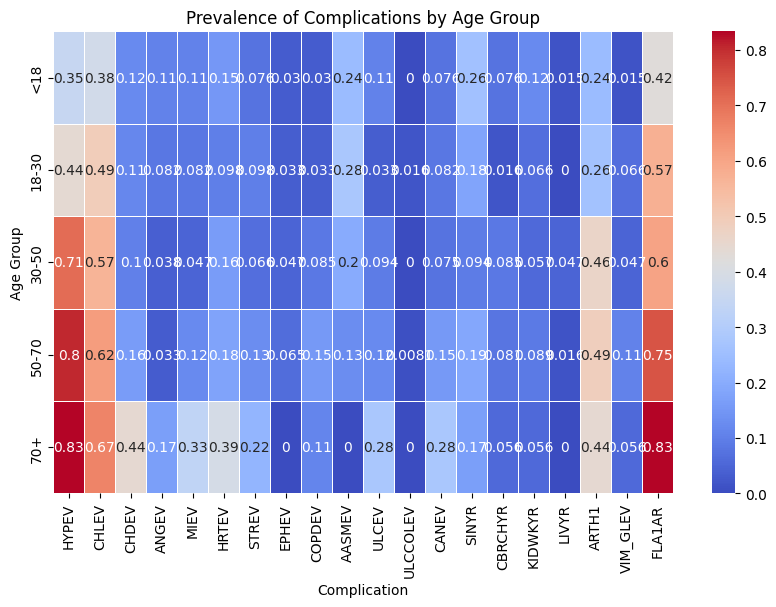

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(complication_proportion, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Prevalence of Complications by Age Group')
plt.xlabel('Complication')
plt.ylabel('Age Group')
plt.show()

#### Total Number of Complications for Each Age Group

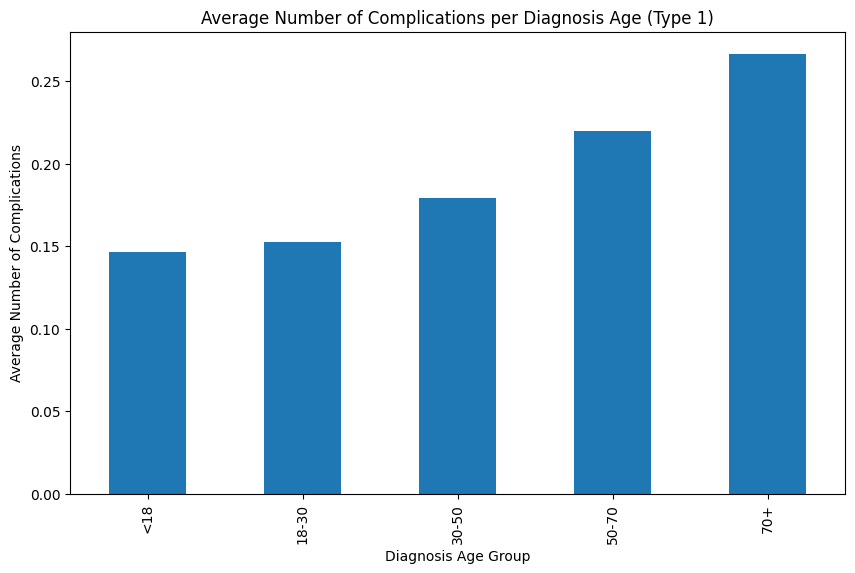

In [10]:
# Step 1: Calculate the average number of complications per patient for each age group
average_complications = type1_df2.groupby('Age_Group')[complications].mean().mean(axis=1)

# Step 2: Plot the average number of complications as a bar chart
average_complications.plot(kind='bar', figsize=(10, 6))

# Add labels and title
plt.title('Average Number of Complications per Diagnosis Age (Type 1)')
plt.ylabel('Average Number of Complications')
plt.xlabel('Diagnosis Age Group')

# Show the plot
plt.show()


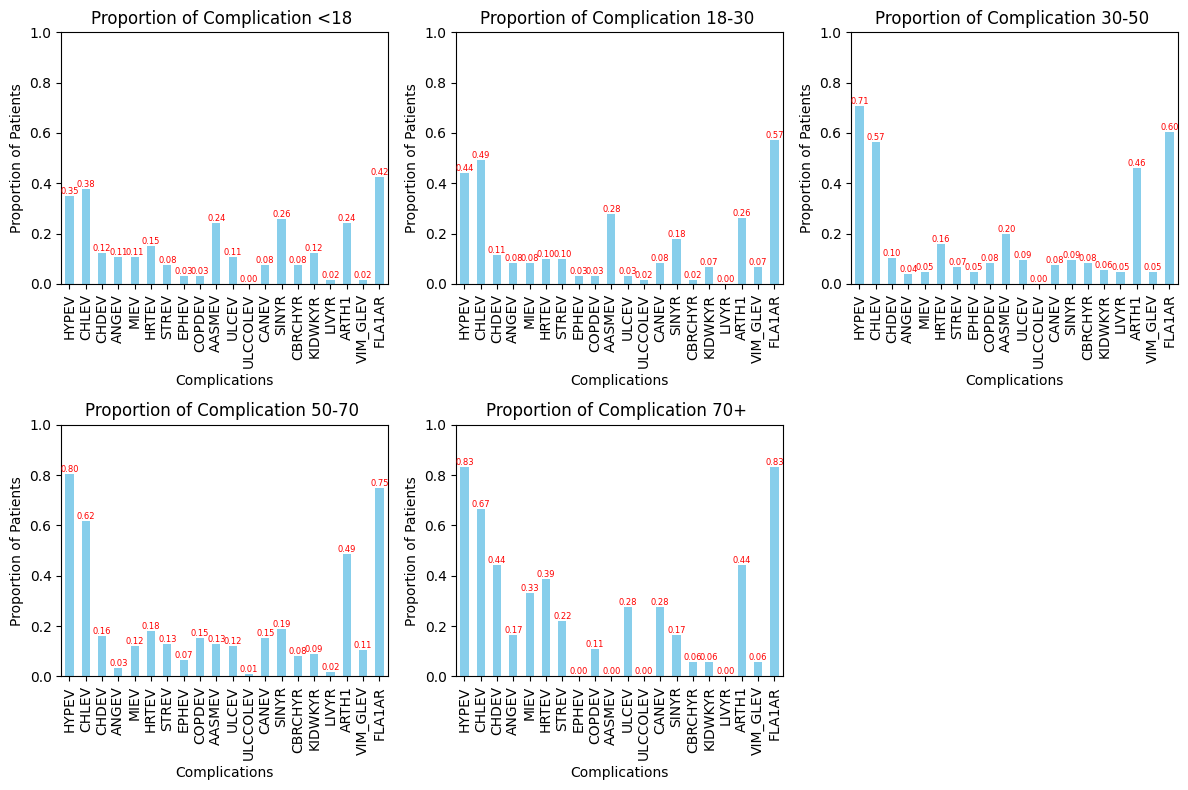

In [26]:
# Step 1: Calculate the proportion of patients with complications for each age group
complication_proportion = type1_df2.groupby('Age_Group')[complications].apply(lambda x: (x > 0).mean())

# Step 2: Create subplots for each age group, arranged in 2 rows and 3 columns
num_age_groups = len(age_order)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))  # 2 rows and 3 columns

# Set consistent y-axis limits across all plots
#y_max = complication_proportion.max().max()  # Maximum value across all age groups and complications

# Plot each age group as a bar chart
for i, age_group in enumerate(age_order):
    ax = axes[i // 3, i % 3]  # Adjust the index for 2 rows and 3 columns
    bars = complication_proportion.loc[age_group].plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title(f'Proportion of Complication {age_group} ')
    ax.set_ylabel('Proportion of Patients')
    ax.set_xlabel('Complications')

    # Set consistent y-axis limits
    ax.set_ylim(0, 1)

    # Add proportion labels on top of each bar in red with smaller font size
    for bar in bars.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}', 
                ha='center', va='bottom', color='red', fontsize=6)

# Remove empty subplots (if any)
if num_age_groups % 3 != 0:
    fig.delaxes(axes[-1, -1])

# Adjust layout for better visibility
plt.tight_layout()
plt.show()


We notice that there is a few complications that are consistently higher across all age groups.

In [105]:
# Loop through each complication and perform the Chi-square test
for comp in complications:
    # Create a contingency table for Age_Group and the complication
    contingency_table = pd.crosstab(type1_df2['Age_Group'], type1_df2[comp])
    
    # Perform the Chi-square test
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    # Print the p-value for the Chi-square test
    print(f'{comp}: Chi-square test p-value = {p:.4f}')

HYPEV: Chi-square test p-value = 0.0000
CHLEV: Chi-square test p-value = 0.0179
CHDEV: Chi-square test p-value = 0.0036
ANGEV: Chi-square test p-value = 0.0614
MIEV: Chi-square test p-value = 0.0050
HRTEV: Chi-square test p-value = 0.0675
STREV: Chi-square test p-value = 0.2052
EPHEV: Chi-square test p-value = 0.6399
COPDEV: Chi-square test p-value = 0.0208
AASMEV: Chi-square test p-value = 0.0211
ULCEV: Chi-square test p-value = 0.0465
ULCCOLEV: Chi-square test p-value = 0.6269
CANEV: Chi-square test p-value = 0.0400
SINYR: Chi-square test p-value = 0.0865
CBRCHYR: Chi-square test p-value = 0.4921
KIDWKYR: Chi-square test p-value = 0.5967
LIVYR: Chi-square test p-value = 0.2514
ARTH1: Chi-square test p-value = 0.0016
VIM_GLEV: Chi-square test p-value = 0.1523
FLA1AR: Chi-square test p-value = 0.0001


### Exploratory Analysis for Type 2 Diabetes

In [3]:
type2 = pd.read_csv('type2_diabetes.csv')
type2

,DIBAGE1,DIFAGE2,HYPEV,CHLEV,CHDEV,ANGEV,MIEV,HRTEV,STREV,EPHEV,...,ULCEV,ULCCOLEV,CANEV,SINYR,CBRCHYR,KIDWKYR,LIVYR,ARTH1,VIM_GLEV,FLA1AR
0,30.0,13.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,58.0,5.0,1,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,54.0,6.0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,1
3,50.0,28.0,1,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
4,53.0,6.0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2755,47.0,0.0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
2756,48.0,10.0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,1
2757,55.0,4.0,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2758,69.0,1.0,1,1,1,0,1,1,0,1,...,0,0,0,0,0,0,0,1,0,0


In [6]:
# Apply the function to type1_df2
type2_df2 = age_by_group(type2)

# Display the updated DataFrame
type2_df2

,HYPEV,CHLEV,CHDEV,ANGEV,MIEV,HRTEV,STREV,EPHEV,COPDEV,AASMEV,...,ULCCOLEV,CANEV,SINYR,CBRCHYR,KIDWKYR,LIVYR,ARTH1,VIM_GLEV,FLA1AR,Age_Group
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,30-50
1,1,1,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,50-70
2,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,50-70
3,1,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,50-70
4,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,50-70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2755,1,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,1,1,30-50
2756,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,1,30-50
2757,1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,50-70
2758,1,1,1,0,1,1,0,1,1,0,...,0,0,0,0,0,0,1,0,0,50-70


Text(0, 0.5, 'Count')

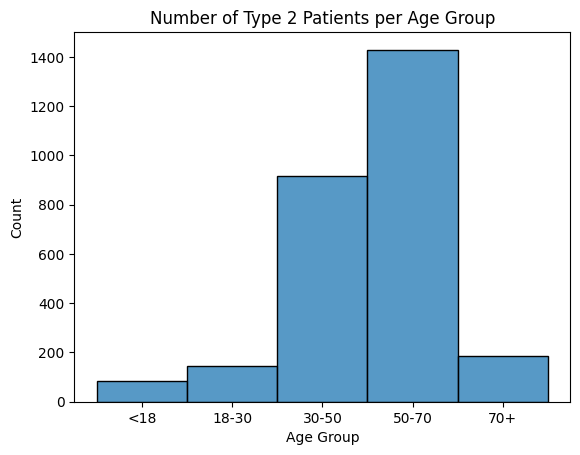

In [7]:
# Check the distribution of patients in each age group
#age_group_counts = type1['Age_Group'].value_counts().sort_index()

# Display the result
sns.histplot(type2_df2['Age_Group'])
plt.title("Number of Type 2 Patients per Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")

In [98]:
# Set custom order for Age_Group to ensure <18 is on top
age_order = ['<18', '18-30', '30-50', '50-70', '70+']  # Using the specified age groups
type2_df2['Age_Group'] = pd.Categorical(type2_df2['Age_Group'], categories=age_order, ordered=True)

# Calculate the proportion of patients with complications for each age group
complication_proportion2 = type2_df2.groupby('Age_Group')[complications].apply(lambda x: (x > 0).mean())

# Display the result
complication_proportion2

,HYPEV,CHLEV,CHDEV,ANGEV,MIEV,HRTEV,STREV,EPHEV,COPDEV,AASMEV,ULCEV,ULCCOLEV,CANEV,SINYR,CBRCHYR,KIDWKYR,LIVYR,ARTH1,VIM_GLEV,FLA1AR
Age_Group,,,,,,,,,,,,,,,,,,,,
<18,0.726190,0.678571,0.154762,0.071429,0.130952,0.214286,0.047619,0.083333,0.119048,0.238095,0.154762,0.023810,0.095238,0.238095,0.190476,0.071429,0.071429,0.511905,0.023810,0.702381
18-30,0.657343,0.580420,0.125874,0.055944,0.090909,0.132867,0.069930,0.020979,0.062937,0.223776,0.083916,0.041958,0.097902,0.139860,0.083916,0.083916,0.055944,0.496503,0.083916,0.748252
30-50,0.763359,0.683751,0.151581,0.080698,0.098146,0.175573,0.106870,0.040349,0.106870,0.222465,0.125409,0.028353,0.151581,0.194111,0.103599,0.109051,0.056707,0.482007,0.071974,0.718648
50-70,0.798460,0.730581,0.176347,0.074878,0.133660,0.189643,0.083275,0.050385,0.103569,0.166550,0.111966,0.021693,0.230931,0.163751,0.069979,0.081875,0.055983,0.569629,0.087474,0.759272
70+,0.775401,0.657754,0.171123,0.080214,0.165775,0.304813,0.106952,0.042781,0.117647,0.128342,0.106952,0.016043,0.358289,0.128342,0.053476,0.069519,0.032086,0.647059,0.096257,0.855615


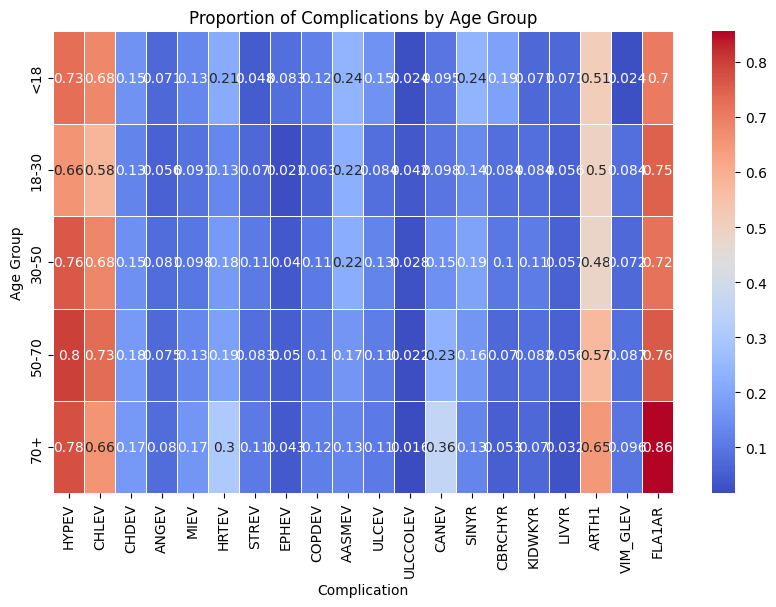

In [99]:
plt.figure(figsize=(10, 6))
sns.heatmap(complication_proportion2, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Proportion of Complications by Age Group')
plt.xlabel('Complication')
plt.ylabel('Age Group')
plt.show()

We can again see the complications prevalent in Type 1 diabetes is not the same as type 2

#### Total Number of Complications per Age Group

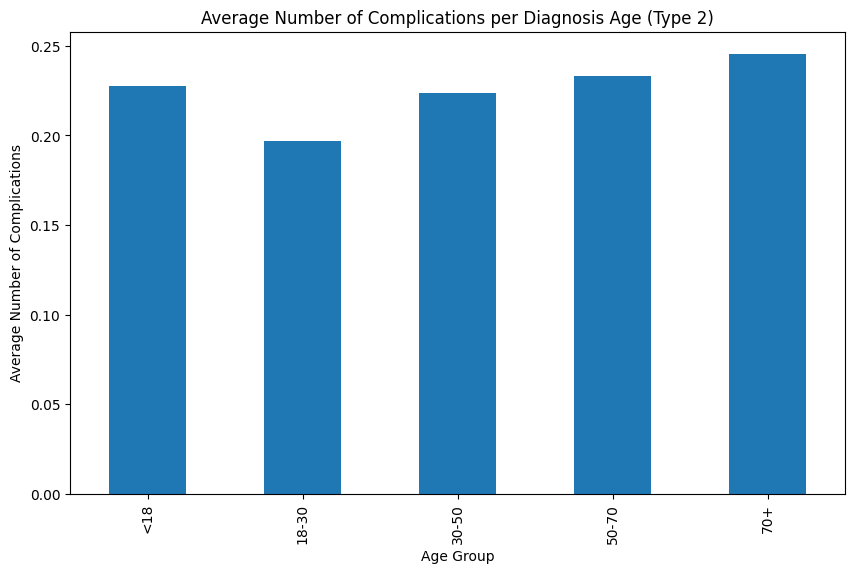

In [32]:
# Step 1: Calculate the average number of complications per patient for each age group
average_complications = type2_df2.groupby('Age_Group')[complications].mean().mean(axis=1)

# Step 2: Plot the average number of complications as a bar chart
average_complications.plot(kind='bar', figsize=(10, 6))

# Add labels and title
plt.title('Average Number of Complications per Diagnosis Age (Type 2)')
plt.ylabel('Average Number of Complications')
plt.xlabel('Age Group')

# Show the plot
plt.show()



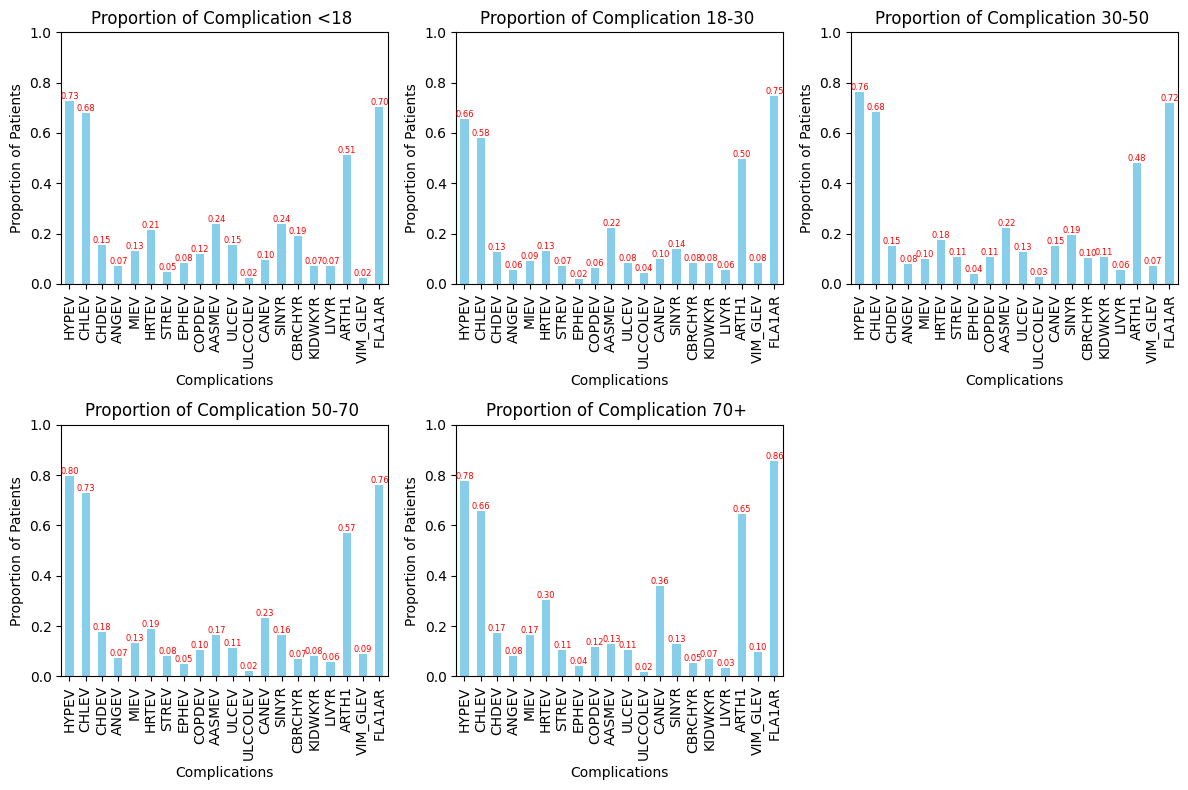

In [27]:
# Step 1: Calculate the proportion of patients with complications for each age group
complication_proportion = type2_df2.groupby('Age_Group')[complications].apply(lambda x: (x > 0).mean())

# Step 2: Create subplots for each age group, arranged in 2 rows and 3 columns
num_age_groups = len(age_order)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))  # 2 rows and 3 columns

# Set consistent y-axis limits across all plots
#y_max = complication_proportion.max().max()  # Maximum value across all age groups and complications

# Plot each age group as a bar chart
for i, age_group in enumerate(age_order):
    ax = axes[i // 3, i % 3]  # Adjust the index for 2 rows and 3 columns
    bars = complication_proportion.loc[age_group].plot(kind='bar', ax=ax, color='skyblue')
    ax.set_title(f'Proportion of Complication {age_group} ')
    ax.set_ylabel('Proportion of Patients')
    ax.set_xlabel('Complications')

    # Set consistent y-axis limits
    ax.set_ylim(0, 1)

    # Add proportion labels on top of each bar in red with smaller font size
    for bar in bars.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}', 
                ha='center', va='bottom', color='red', fontsize=6)

# Remove empty subplots (if any)
if num_age_groups % 3 != 0:
    fig.delaxes(axes[-1, -1])

# Adjust layout for better visibility
plt.tight_layout()
plt.show()


#### Chi-square test

In [103]:
# Loop through each complication and perform the Chi-square test
for comp in complications:
    # Create a contingency table for Age_Group and the complication
    contingency_table = pd.crosstab(type2_df2['Age_Group'], type2[comp])
    
    # Perform the Chi-square test
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    # Print the p-value for the Chi-square test
    print(f'{comp}: Chi-square test p-value = {p:.4f}')


HYPEV: Chi-square test p-value = 0.0014
CHLEV: Chi-square test p-value = 0.0008
CHDEV: Chi-square test p-value = 0.3741
ANGEV: Chi-square test p-value = 0.8775
MIEV: Chi-square test p-value = 0.0224
HRTEV: Chi-square test p-value = 0.0004
STREV: Chi-square test p-value = 0.1317
EPHEV: Chi-square test p-value = 0.1959
COPDEV: Chi-square test p-value = 0.5169
AASMEV: Chi-square test p-value = 0.0010
ULCEV: Chi-square test p-value = 0.4287
ULCCOLEV: Chi-square test p-value = 0.4925
CANEV: Chi-square test p-value = 0.0000
SINYR: Chi-square test p-value = 0.0418
CBRCHYR: Chi-square test p-value = 0.0001
KIDWKYR: Chi-square test p-value = 0.1586
LIVYR: Chi-square test p-value = 0.6622
ARTH1: Chi-square test p-value = 0.0000
VIM_GLEV: Chi-square test p-value = 0.1909
FLA1AR: Chi-square test p-value = 0.0015
